### 8. **Pseudocódigo completo del proceso LDA**
```plaintext
Input: Conjunto de datos con N clases y sus muestras
Output: Datos proyectados en el subespacio con clases separadas

1. Formulación del conjunto de datos
    Para cada clase, estructurar las muestras de datos

2. Cálculo de las medias
    Calcular las medias de cada clase (mu_clase)
    Calcular la media global (mu_global)

3. Cálculo de la dispersión intra-clase (Sw)
    Inicializar Sw
    Para cada clase:
        Para cada muestra en la clase:
            Calcular desviación de la media
            Actualizar Sw

4. Cálculo de la dispersión inter-clase (Sb)
    Inicializar Sb
    Para cada clase:
        Calcular desviación de la media de la clase respecto a la media global
        Actualizar Sb

5. Maximización del criterio de optimización
    Calcular el criterio J(w) = inv(Sw) * Sb
    Calcular vectores propios y seleccionar los L-1 mayores vectores propios

6. Proyección de los datos
    Proyectar los datos en el subespacio de LDA utilizando los vectores propios

7. Clasificación
    Para cada muestra proyectada:
        Calcular distancias a las medias proyectadas de las clases
        Asignar la clase más cercana

Fin del proceso
```

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import io
from IPython.display import display, Image, clear_output
import ipywidgets as widgets
import seaborn as sns

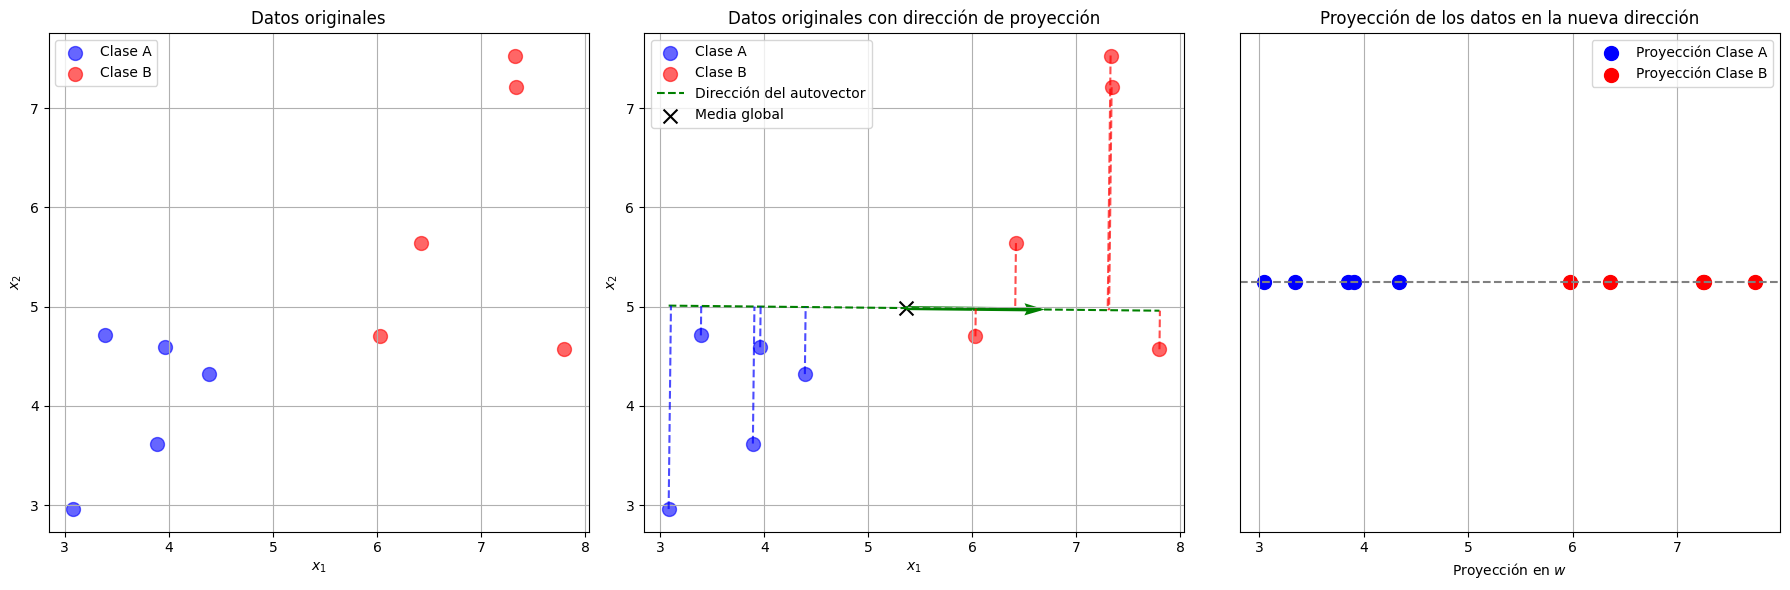

In [ ]:
X_A = np.random.multivariate_normal([4, 4.5], [[1, 0], [0, 1]], 5).round(2)
X_B = np.random.multivariate_normal([6, 6], [[1, 0], [0, 1]], 5).round(2)
X = np.vstack((X_A, X_B))
y = np.array(['A'] * 5 + ['B'] * 5)

df = pd.DataFrame(X, columns=['x_1', 'x_2'])
df['Clase'] = y

mu_A = np.mean(X_A, axis=0)
mu_B = np.mean(X_B, axis=0)
mu_global = np.mean(X, axis=0)

S_W = np.zeros((2, 2))
for x in X_A:
    S_W += np.outer(x - mu_A, x - mu_A)
for x in X_B:
    S_W += np.outer(x - mu_B, x - mu_B)

mean_diff = (mu_A - mu_B).reshape(2, 1)
S_B = np.dot(mean_diff, mean_diff.T)

eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
w = eigvecs[:, np.argmax(eigvals)]

line_x = np.linspace(min(X[:, 0]), max(X[:, 0]), 100)
line_y = mu_global[1] + (w[1] / w[0]) * (line_x - mu_global[0])

def proyectar_punto(punto, w, mu_global):
    proy_scalar = np.dot(punto - mu_global, w) / np.dot(w, w)
    proy_punto = mu_global + proy_scalar * w
    return proy_punto

projection_A = X_A @ w
projection_B = X_B @ w

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X_A[:, 0], X_A[:, 1], label='Clase A', color='blue', s=100, alpha=0.6)
plt.scatter(X_B[:, 0], X_B[:, 1], label='Clase B', color='red', s=100, alpha=0.6)
plt.title('Datos originales')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.scatter(X_A[:, 0], X_A[:, 1], label='Clase A', color='blue', s=100, alpha=0.6)
plt.scatter(X_B[:, 0], X_B[:, 1], label='Clase B', color='red', s=100, alpha=0.6)
plt.plot(line_x, line_y, 'g--', label='Dirección del autovector')
plt.scatter(mu_global[0], mu_global[1], color='black', marker='x', s=100, label='Media global')
plt.quiver(mu_global[0], mu_global[1], w[0], w[1], angles='xy', scale_units='xy', scale=0.75, color='green')

for punto in X_A:
    proy_punto = proyectar_punto(punto, w, mu_global)
    plt.plot([punto[0], proy_punto[0]], [punto[1], proy_punto[1]], 'b--', alpha=0.7)
for punto in X_B:
    proy_punto = proyectar_punto(punto, w, mu_global)
    plt.plot([punto[0], proy_punto[0]], [punto[1], proy_punto[1]], 'r--', alpha=0.7)

plt.title('Datos originales con dirección de proyección')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.scatter(projection_A, np.zeros_like(projection_A), label='Proyección Clase A', color='blue', s=100)
plt.scatter(projection_B, np.zeros_like(projection_B), label='Proyección Clase B', color='red', s=100)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Proyección de los datos en la nueva dirección')
plt.xlabel('Proyección en $w$')
plt.yticks([])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### 1. **Conjunto de datos**
```plaintext
Input: Conjunto de datos de características con N muestras y M características, más un vector objetivo (y)
Output: Conjunto de datos dividido y estandarizado para entrenamiento y prueba

Iniciar matriz de datos y vector objetivo

1) Cargar conjunto de datos de características y vector objetivo:
    - Convertir el conjunto de datos en un DataFrame con M columnas (características)
    - Agregar una columna al DataFrame que contenga el vector objetivo

2) Dividir el conjunto de datos en conjuntos de entrenamiento y prueba:
    - Dividir los datos en un conjunto de entrenamiento (80% de las muestras) y un conjunto de prueba (20% de las muestras) de manera aleatoria con una semilla fija para reproducibilidad

3) Estandarizar los datos:
    - Calcular la media de cada característica en el conjunto de entrenamiento
    - Calcular la desviación estándar de cada característica en el conjunto de entrenamiento
    - Transformar el conjunto de entrenamiento restando la media y dividiendo por la desviación estándar para cada característica
    - Transformar el conjunto de prueba usando la media y la desviación estándar calculadas en el conjunto de entrenamiento

4) Almacenar los datos estandarizados de entrenamiento y prueba
```

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


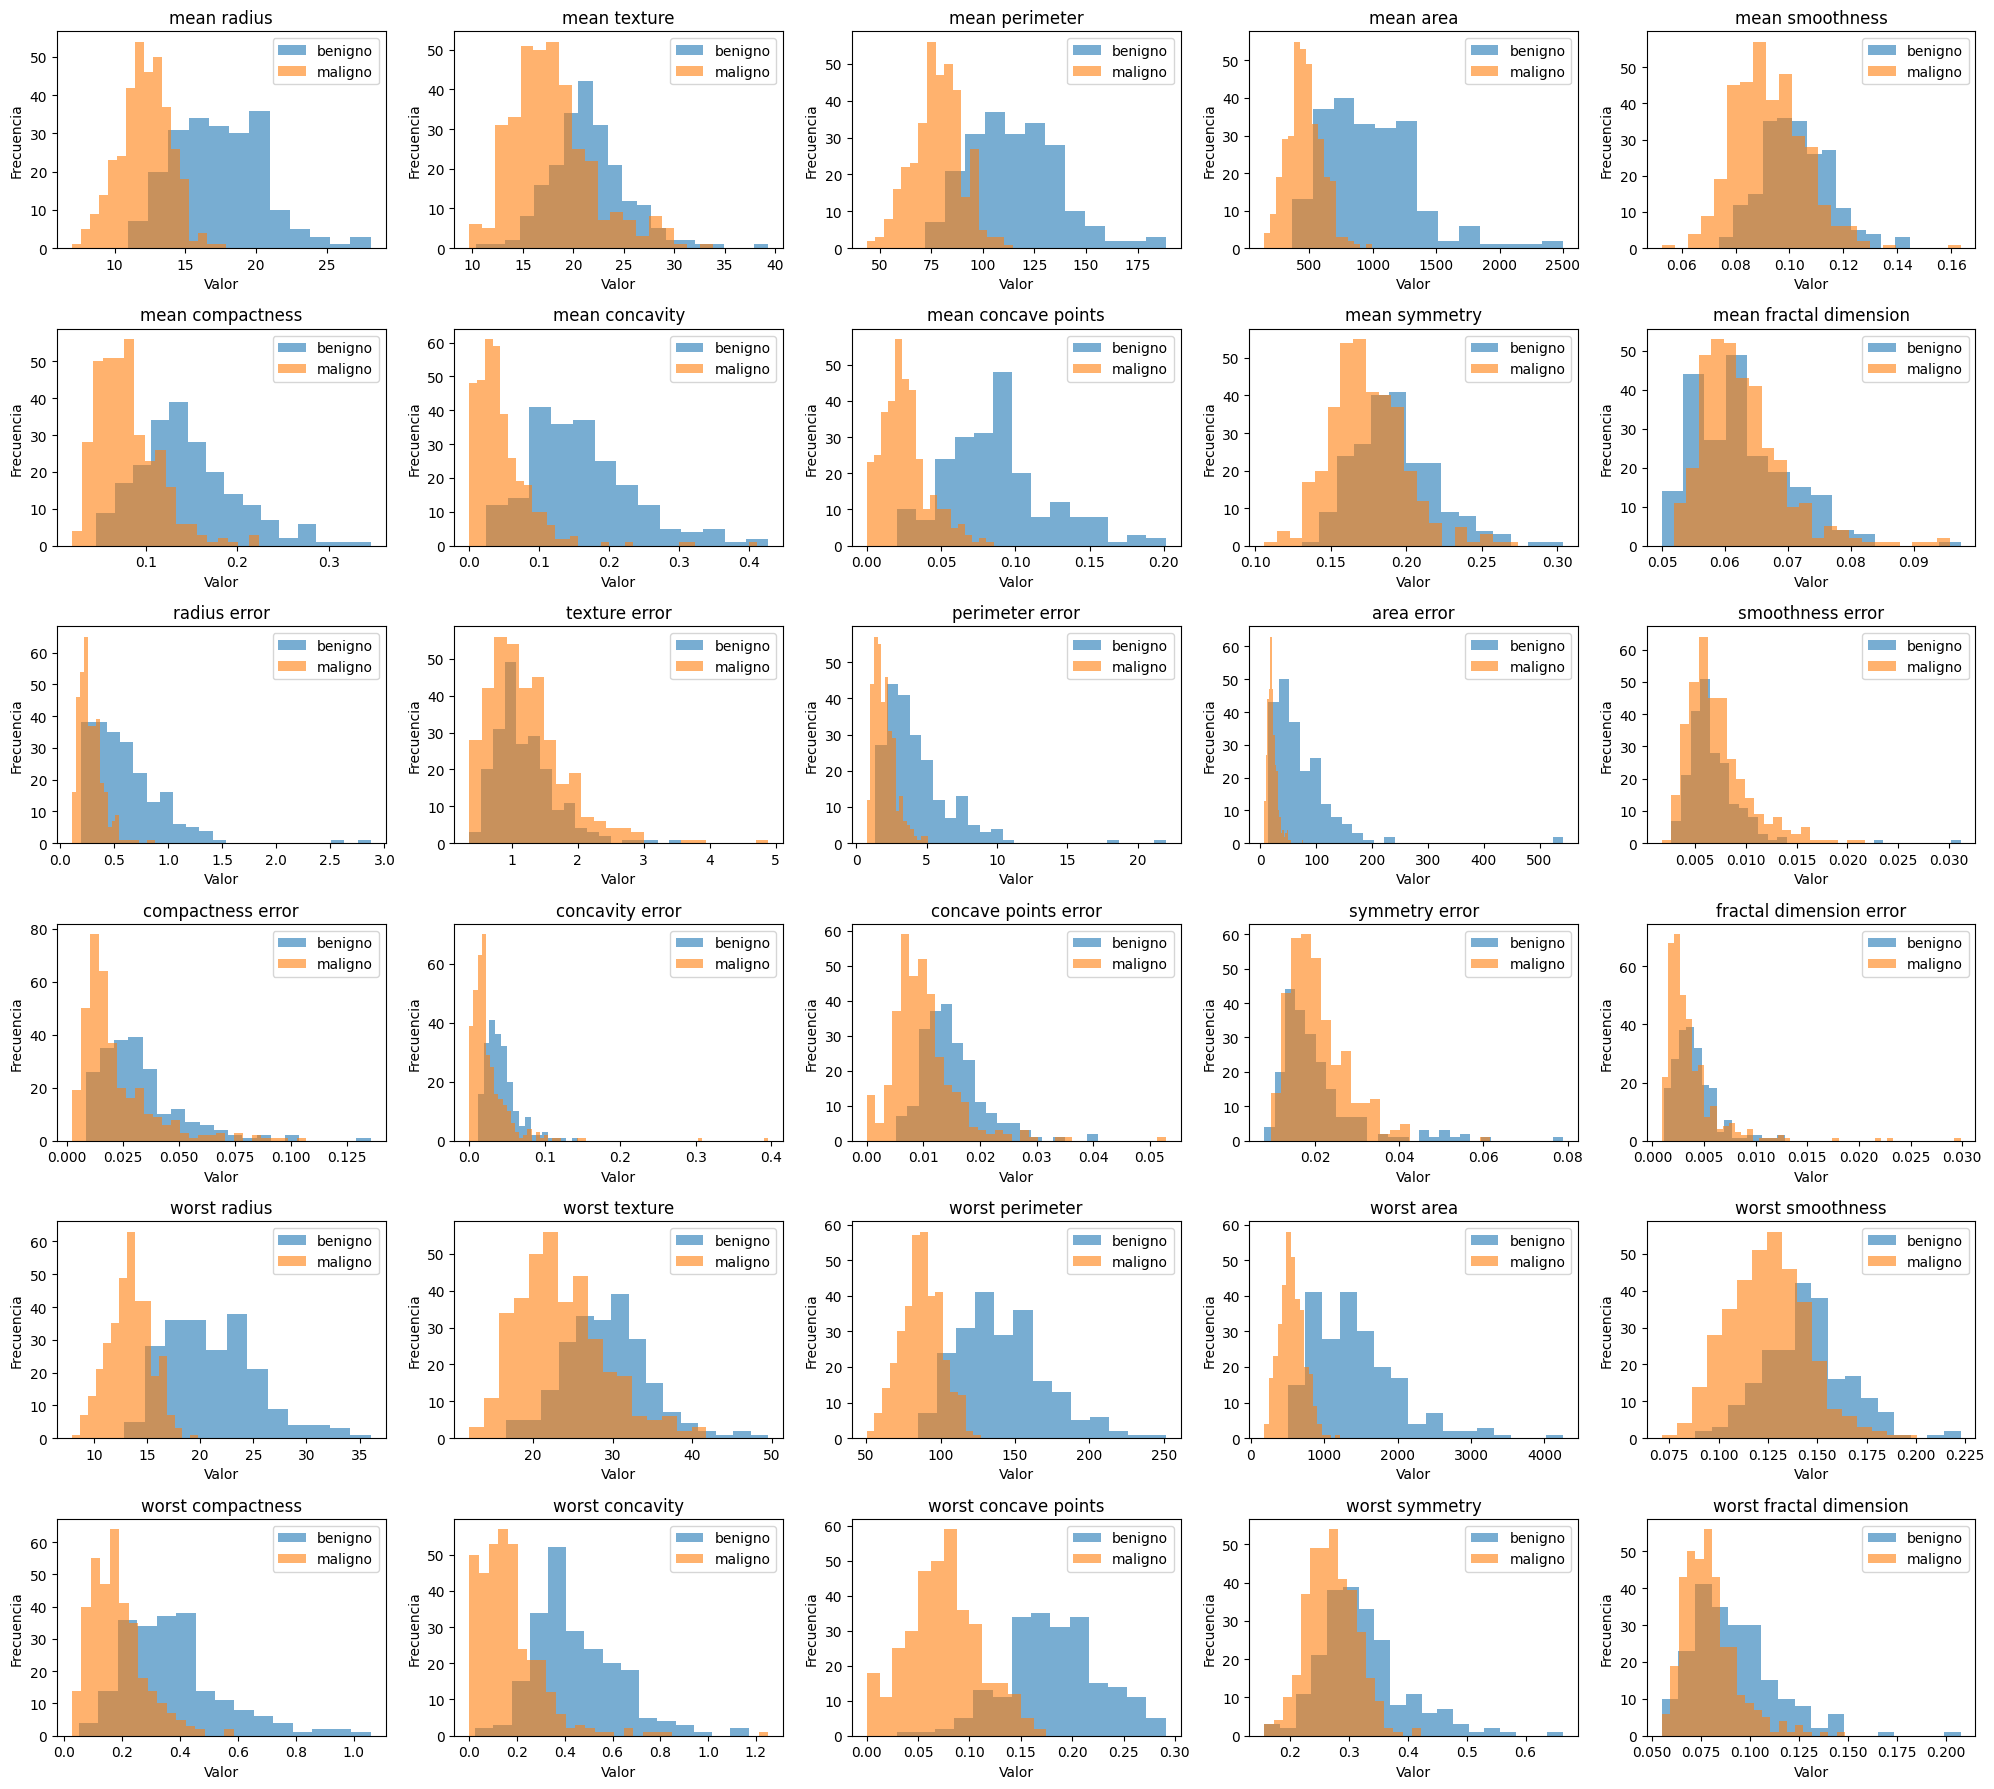

In [ ]:
categorias = {0: 'benigno', 1: 'maligno'}
columnas = df.columns[:-1]

num_col = len(columnas)
num_filas = (num_col + 3) // 5

plt.figure(figsize=(20, 3 * num_filas))

for i, col in enumerate(columnas):
    plt.subplot(num_filas, 5, i + 1)
    for categoria, label in categorias.items():
        subset = df[df['target'] == categoria]
        plt.hist(subset[col], bins='auto', alpha=0.6, label=label)
    plt.title(col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Cantidad de muestras para entrenamiento del clasificador: {X_train.shape[0]}')
print(f'Cantidad de muestras para prueba del clasificador: {X_test.shape[0]}')

Cantidad de muestras para entrenamiento del clasificador: 455
Cantidad de muestras para prueba del clasificador: 114


In [ ]:
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)

X_train_standarizado = (X_train - X_train_mean) / X_train_std
X_test_standarizado = (X_test - X_train_mean) / X_train_std

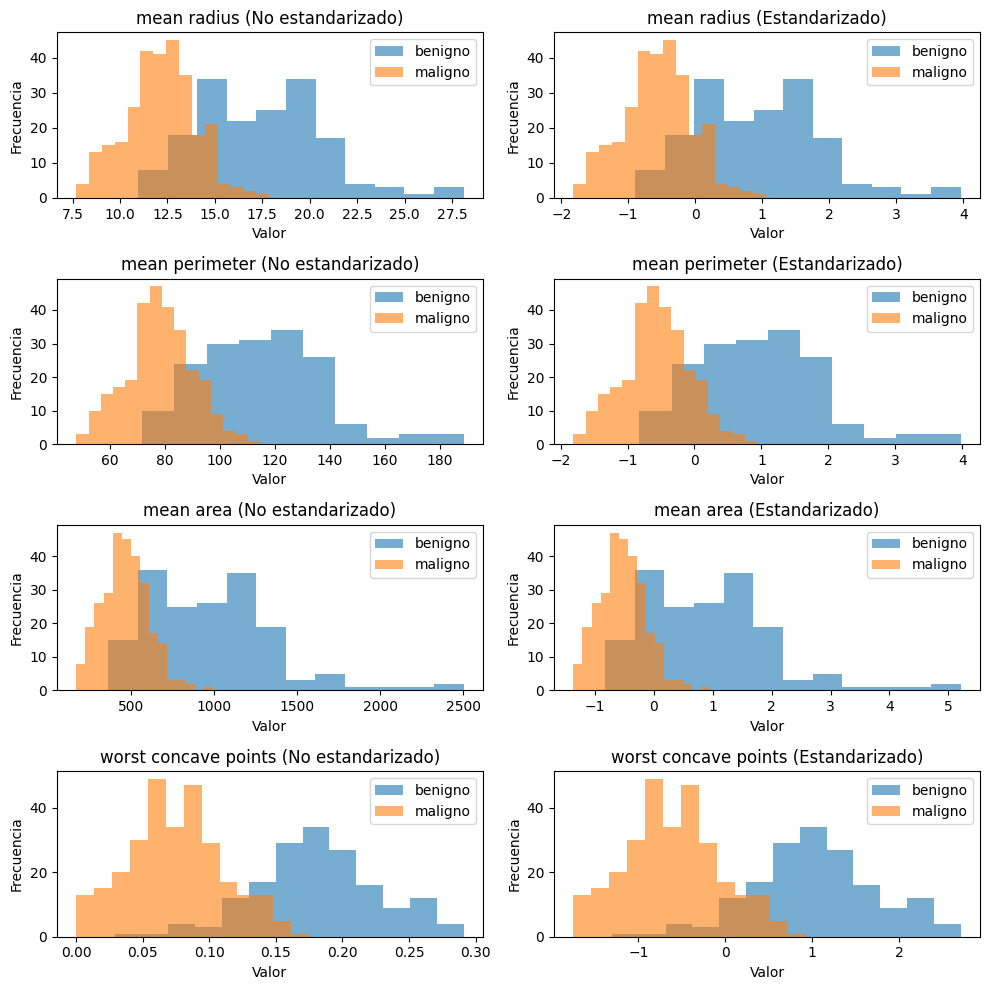

In [ ]:
columnas_selec = ["mean radius", "mean perimeter", "mean area", "worst concave points"]
plt.figure(figsize=(10, 10))

for i, col in enumerate(columnas_selec):
    plt.subplot(4, 2, 2 * i + 1)
    for categoria, label in categorias.items():
        subset = X_train[y_train == categoria]
        plt.hist(subset[:, df.columns.get_loc(col)], bins='auto', alpha=0.6, label=f'{label}')
    plt.title(f'{col} (No estandarizado)')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.legend()

    plt.subplot(4, 2, 2 * i + 2)
    for categoria, label in categorias.items():
        subset_std = X_train_standarizado[y_train == categoria]
        plt.hist(subset_std[:, df.columns.get_loc(col)], bins='auto', alpha=0.6, label=f'{label}')
    plt.title(f'{col} (Estandarizado)')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.legend()

plt.tight_layout()
plt.show()


### 2. **Cálculo de la media de cada clase y la media global**
```plaintext
Input: Conjunto de datos de entrenamiento estandarizado (X_train_std) y vector de etiquetas de clase (y_train)
Output: Medias de cada clase (mu_clase) y media global (mu_global)

1) Calcular la media global para cada columna.

2) Separar los datos por clases.

3) Calcular la media de cada clase.
```

In [ ]:
# Media global
media_global = np.mean(X_train_standarizado, axis=0)

# Separacion de los datos por clases
clase_0 = X_train_standarizado[y_train == 0]
clase_1 = X_train_standarizado[y_train == 1]

# Medias de cada clase
media_0 = np.mean(clase_0, axis=0)
media_1 = np.mean(clase_1, axis=0)

### 3. **Cálculo de la dispersión intra-clase (Scatter intra-clase)**
```plaintext
Input: Datos de cada clase (class_0, class_1) y sus respectivas medias (mean_0, mean_1)
Output: Matriz de dispersión intra-clase (S_within)

1) Iniciar S_within como una matriz de ceros del tamaño de (n_características x n_características)

2) Para cada clase:
    - Calcular la desviación de cada muestra respecto a la media.
    - Calcular el producto de la desviación y su transpuesta.
    - Sumar este producto a S_within.

Al final, S_within contiene la suma de las matrices de dispersión intra-clase para todas las clases
```

In [ ]:
S_intra = np.zeros((X_train.shape[1], X_train.shape[1]))

S_intra += (clase_0 - media_0).T @ (clase_0 - media_0)
S_intra += (clase_1 - media_1).T @ (clase_1 - media_1)

### 4. **Cálculo de la dispersión inter-clase (Scatter inter-clase)**
```plaintext
Input: Medias de las clases (mean_0, mean_1), media global (mean_overall) y número de muestras en cada clase (n_0, n_1)
Output: Matriz de dispersión inter-clase (S_between)

1) Iniciar S_between como una matriz de ceros del tamaño de (n_características x n_características)

2) Para cada clase:
    - Calcular la desviación de la media de la clase respecto a la media global.
    - Calcular el producto de la desviación por su transpuesta.
    - Multiplicar el producto por el número de muestras en la clase
    - Sumar este valor a S_between

Al final, S_between contiene la suma de las matrices de dispersión ponderadas entre las clases
```

In [ ]:
n_0 = clase_0.shape[0]
n_1 = clase_1.shape[0]

S_entre = np.zeros((X_train.shape[1], X_train.shape[1]))

S_entre += np.dot((media_0 - media_global).reshape(-1, 1), (media_0 - media_global).reshape(1, -1)) * n_0
S_entre += np.dot((media_1 - media_global).reshape(-1, 1), (media_1 - media_global).reshape(1, -1)) * n_1

### 5. **Maximización del criterio de optimización (Cálculo de los vectores propios)**
```plaintext
Input: Matrices de dispersión intra-clase (S_within) y dispersión inter-clase (S_between)
Output: Vectores propios (W) correspondientes a los mayores valores propios

1) Calcular el criterio de optimización:
    - Multiplicar la inversa de S_within por S_between: J = inv(S_within) * S_between

2) Calcular los valores propios y vectores propios:
    - Usar un método de descomposición para obtener los valores propios (eigvals) y vectores propios (eigvecs) de J

3) Ordenar los valores y vectores propios:
    - Ordenar los valores propios en orden descendente
    - Reordenar los vectores propios de acuerdo con el orden de los valores propios

4) Seleccionar los vectores propios:
    - Tomar el autovector correspondiente al mayor autovalor (el primero en la lista)
    - Asignar el autovector seleccionado a W para proyectar los datos en una dimensión

W contiene los vectores propios para maximizar la separabilidad entre las clases
```

In [ ]:
def sol_trinffil(A, b):

    n = len(b)
    x = np.zeros(n)
    j = 0

    for i, bi in enumerate(b):

        if bi != 0:
            j = i
            break

    for i in range(j, n):

        x[i] = (b[i] - A[i][:i] @ x[:i]) / A[i][i]

    return x

def sol_trsupfil(A, b):

    n = len(b)
    x = np.zeros(n)
    i = 0

    for j in reversed(range(n)):

        if b[j] != 0:
            i = j
            break

    for j in reversed(range(i+1)):
        x[j] = (b[j] - A[j][j+1:] @ x[j+1:]) / A[j][j]

    return x

def dlup(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    P = np.eye(n, dtype=float)

    if n == 1:
        return np.eye(1), A, P

    for k in range(n-1):
        l = np.argmax(np.abs(A[k:, k])) + k

        if A[l, k] != 0:
            if l != k:
                A[[k, l]] = A[[l, k]]
                P[[k, l]] = P[[l, k]]

            A[k+1:, k] = A[k+1:, k] / A[k, k]
            A[k+1:, k+1:] -= np.outer(A[k+1:, k], A[k, k+1:])

    L = np.tril(A, k=-1) + np.eye(n)
    U = np.triu(A)

    return L, U, P

def inv_lu(A):

    A = np.array(A, dtype=float)
    n = A.shape[0]
    L, U, P = dlup(A)

    I = np.eye(n)

    A_inv = np.zeros((n, n))

    for i in range(n):

        y = sol_trinffil(L, P @ I[:, i])
        A_inv[:, i] = sol_trsupfil(U, y)

    return A_inv

In [ ]:
def house(x):

    n = len(x)
    rho = 0
    u = x.copy()
    u[0] = 1.
    mu = 0

    if n == 1:
        sigma = 0
    else:
        sigma = np.sum(x[1:]**2)

    if sigma>0 or x[0]<0:
        mu = np.sqrt(x[0]**2 + sigma)

    if x[0]<=0:
        gamma = x[0] - mu
    else:
        gamma = -sigma/(x[0] + mu)

    rho = 2*gamma**2/(gamma**2 + sigma)
    u = u/gamma
    u[0] = 1

    return u, rho

def givens(x1,x2):

    c = 1.
    s = 0.
    ax1 = abs(x1)
    ax2 = abs(x2)

    if ax1 + ax2 > 0:
        if ax2 > ax1:
            tau = -x1/x2
            s = -np.sign(x2)/np.sqrt(1 + tau**2)
            c = tau*s
        else:
            tau = -x2/x1
            c = np.sign(x1)/np.sqrt(1 + tau**2)
            s = tau*c

    return c, s


def fhess(A, p=1):
    m, n = A.shape
    if m != n:
        print("La matriz no es cuadrada")
        return None
    Q = np.eye(m)
    H = A.copy()

    if p == 0:
        for j in range(n-2):
            u, rho = house(H[j+1:, j])
            w = rho * u
            H[j+1:, j:] = H[j+1:, j:] - np.outer(w, u.T @ H[j+1:, j:])
            H[:, j+1:] = H[:, j+1:] - H[:, j+1:]@ np.outer(w, u.T)
            Q[:, j+1:] = Q[:, j+1:] - Q[:, j+1:]@np.outer(w, u.T)

    elif p == 1:
        for j in range(n - 2):
            for i in range(j + 2, n):
                c, s = givens(H[j + 1, j], H[i, j])
                rot = np.array([[c, -s], [s, c]])
                H[[j + 1, i], j:] = rot @ H[[j + 1, i], j:]
                H[:, [j + 1, i]] = H[:, [j + 1, i]] @ rot.T
                Q[:, [j + 1, i]] = Q[:, [j + 1, i]] @ rot.T
    else:
        print("Elegir un p que sea 0 o 1")
        return None

    return Q, H

def autqr(A, err= 1e-10, M = 100):
    n = A.shape[0]
    Q, H = fhess(A)

    G_rot = np.zeros((n, 2))

    for k in range(M):
        for j in range(n-1):
            c, s = givens(H[j, j], H[j+1, j])
            G_rot[j, :] = np.array([c, s])
            G_cs = np.array([[c, -s], [s, c]])
            H[[j, j+1], j:] = G_cs @ H[[j, j+1], j:]

        for l in range(n-1):
            c, s = G_rot[l, :]
            G_cs = np.array([[c, -s], [s, c]])
            H[: , [l, l+1]] = H[: , [l, l+1]] @ G_cs.T
            Q[: , [l, l+1]] = Q[: , [l, l+1]] @ G_cs.T

        if np.linalg.norm(H - np.diag(np.diag(H)), 'fro') < err:
            print ("llegamos a la tolerancia")
            break

    return Q, H

In [ ]:
Q, H = autqr(inv_lu(S_intra).dot(S_entre))

print(f"Autovalores : \n\n{np.diag(H)}")

Autovalores : 

[ 3.52443336e+00 -1.28978074e-12  3.55503907e-13 -4.98163161e-14
 -5.96124528e-14  4.14766824e-14  2.27547009e-14  1.80877977e-14
  3.92751749e-15 -3.87255021e-15 -1.58940052e-14 -7.90073093e-15
 -1.01294711e-14  7.32688565e-15  5.08346677e-15  5.40658592e-15
 -5.44346738e-15 -3.88655091e-15  8.44034733e-16 -5.78977923e-16
  9.96786014e-16  2.23779667e-15 -6.61348016e-16 -1.32608503e-15
  9.55506226e-18  1.18921612e-17 -2.68761253e-16  1.42545497e-16
  3.28754641e-17 -2.23794483e-17]


In [ ]:
eigvals = np.diag(H)
eigvecs = Q

indices_ordenados = np.argsort(eigvals)[::-1]
eigvals = eigvals[indices_ordenados]
eigvecs = eigvecs[:, indices_ordenados]

In [ ]:
print('Varianza Explicada:\n')
eigv_sum = sum(eigvals)
for i in range(len(eigvals)):
    varianza_explicada = eigvals[i] / eigv_sum
    print('Autovalor {0}: {1:.2%}'.format(i + 1, varianza_explicada.real))

Varianza Explicada:

Autovalor 1: 100.00%
Autovalor 2: 0.00%
Autovalor 3: 0.00%
Autovalor 4: 0.00%
Autovalor 5: 0.00%
Autovalor 6: 0.00%
Autovalor 7: 0.00%
Autovalor 8: 0.00%
Autovalor 9: 0.00%
Autovalor 10: 0.00%
Autovalor 11: 0.00%
Autovalor 12: 0.00%
Autovalor 13: 0.00%
Autovalor 14: 0.00%
Autovalor 15: 0.00%
Autovalor 16: 0.00%
Autovalor 17: -0.00%
Autovalor 18: -0.00%
Autovalor 19: -0.00%
Autovalor 20: -0.00%
Autovalor 21: -0.00%
Autovalor 22: -0.00%
Autovalor 23: -0.00%
Autovalor 24: -0.00%
Autovalor 25: -0.00%
Autovalor 26: -0.00%
Autovalor 27: -0.00%
Autovalor 28: -0.00%
Autovalor 29: -0.00%
Autovalor 30: -0.00%


In [ ]:
W = eigvecs[:, :1]

### 6. **Proyección del conjunto de datos en el nuevo espacio**
```plaintext
Input: Conjunto de datos originales y vectores propios (w)
Output: Datos proyectados en el nuevo subespacio

Para cada muestra de datos:
    - Proyectar la muestra en el subespacio de LDA utilizando los vectores propios: x_proyectado = w^T * x

Almacenar el conjunto de datos proyectados
```

In [ ]:
X_train_proyec = X_train_standarizado.dot(W)
X_test_proyec = X_test_standarizado.dot(W)

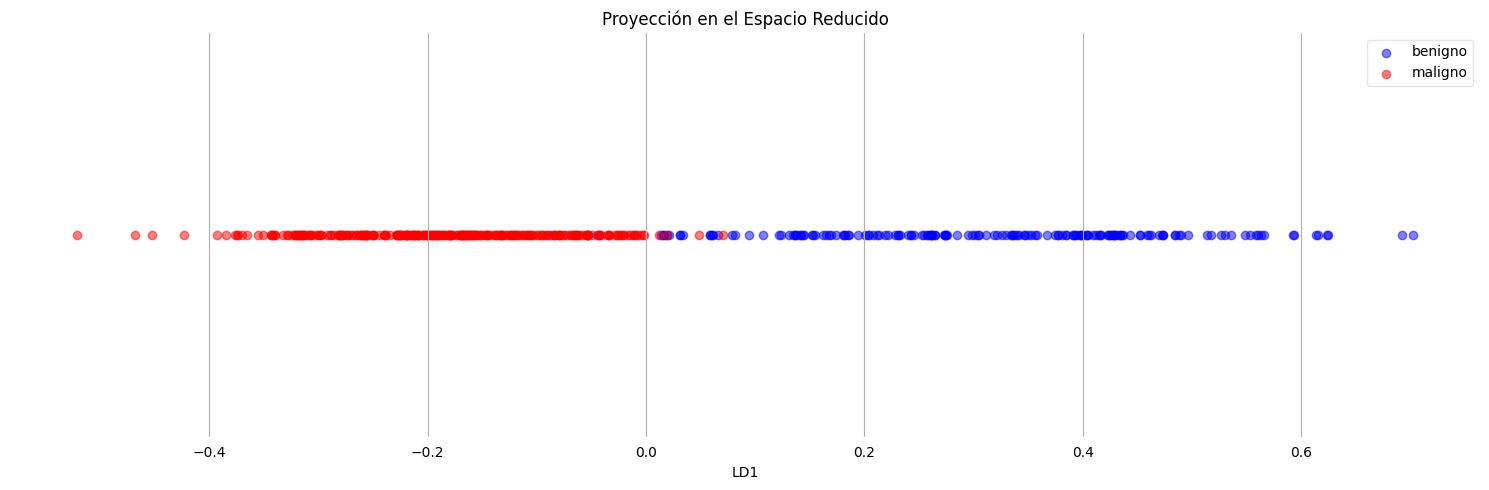

In [ ]:
plt.figure(figsize=(15, 5))
ax = plt.subplot(111)

for label, color in zip(range(2), ('blue', 'red')):
    plt.scatter(x=X_train_proyec[y_train == label, 0],
                y=np.zeros_like(X_train_proyec[y_train == label, 0]),
                color=color,
                alpha=0.5,
                label=categorias[label]
                )

plt.xlabel('LD1')
plt.yticks([])
plt.title('Proyección en el Espacio Reducido')

leg = plt.legend(loc='upper right', fancybox=True)
leg.get_frame().set_alpha(0.5)

plt.tick_params(axis="both", which="both", bottom=False, top=False,
                labelbottom=True, left=False, right=False, labelleft=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.grid()
plt.tight_layout()
plt.show()

### 7. **Clasificación de los datos en el subespacio**
```plaintext
Input: Datos proyectados (X_test_proyec), medias proyectadas de las clases (mean_proyec_0, mean_proyec_1)
Output: Clase predicha para cada muestra y precisión del modelo

1) Definir función de clasificación (clasificador):
    - Input: Muestra proyectada (x), medias proyectadas de las clases (mean_0, mean_1)
    - Inicializar la clase predicha como 1 (por defecto)
    - Si la distancia entre la muestra y la media de la clase 0 es menor que la distancia a la media de la clase 1:
        - Asignar la clase predicha como 0
    - Retornar la clase predicha

2) Clasificar las muestras del conjunto de prueba:
    - Para cada muestra en X_test_proyec:
        - Usar la función clasificador para determinar la clase predicha
    - Guardar todas las clases predichas en y_pred

3) Calcular la precisión:
    - Comparar y_pred con y_test para obtener el porcentaje de aciertos

Output: Imprimir "Exactitud: <valor de la precisión>%" como resultado final
```

In [ ]:
def clasificador(x, mean_0, mean_1):

    clase = 1

    if np.abs(x - mean_0) < np.abs(x - mean_1):
        clase = 0

    return clase

In [ ]:
media_proyec_0 = np.mean(X_train_proyec[y_train == 0])
media_proyec_1 = np.mean(X_train_proyec[y_train == 1])

y_pred = np.array([clasificador(x, media_proyec_0, media_proyec_1) for x in X_test_proyec])

exactitud = np.mean(y_pred == y_test)
print(f'Exactitud: {exactitud * 100:.2f}%')

Exactitud: 95.61%


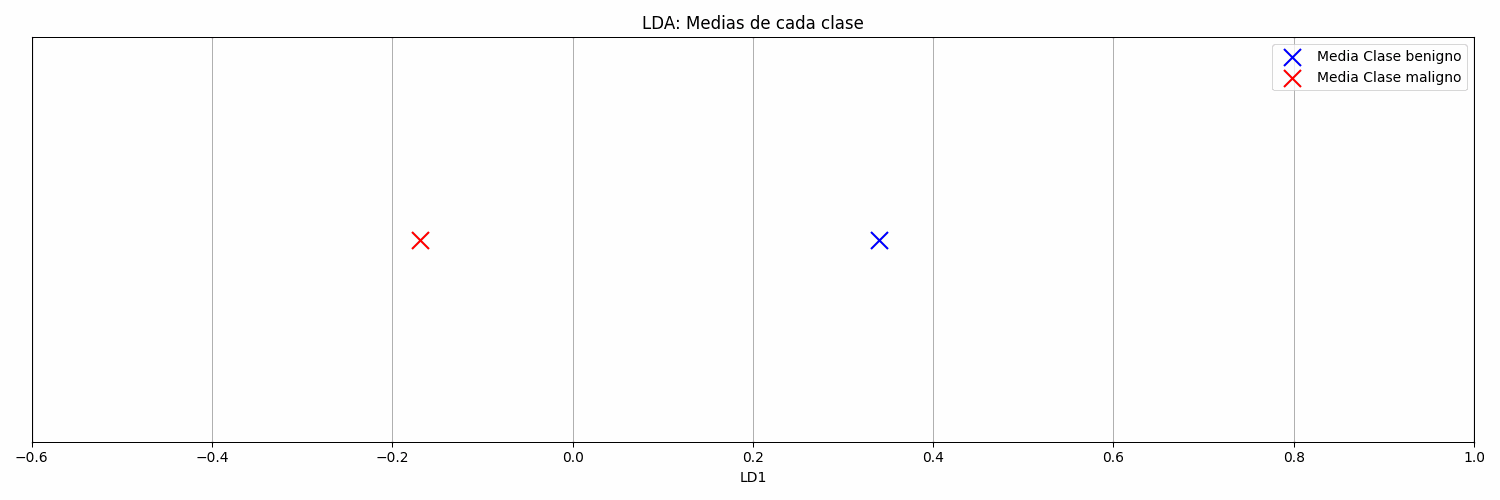

In [ ]:
X = np.squeeze(X_test_proyec)
puntos_medios = [np.mean(X[y_test == label]) for label in range(2)]

imagenes = []

clasificacion = ('benigno', 'maligno')

plt.figure(figsize=(15, 5))
plt.title('LDA: Clasificación de un nuevo punto')
plt.xlim(-0.6, 1.0)
plt.ylim(-1, 1)
plt.grid()

for class_label, color, clasi in zip(range(2), ('blue', 'red'), clasificacion):
    plt.scatter(x=puntos_medios[class_label], y=0, marker='x', color=color, s=150, label=f'Media Clase {clasi}')

plt.xlabel('LD1')
plt.title('LDA: Medias de cada clase')
plt.yticks([])
plt.legend()
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png')
plt.close()
imagenes.append(imageio.imread(buf))

for idx in range(len(X)):
    plt.figure(figsize=(15, 5))

    for class_label, clasi, color in zip(range(2), clasificacion, ('blue', 'red')):
        plt.scatter(x=X[:idx + 1][y_test[:idx + 1] == class_label],
                    y=np.zeros_like(X[:idx + 1][y_test[:idx + 1] == class_label]),
                    color=color,
                    alpha=0.5)
        plt.scatter(x=puntos_medios[class_label], y=0, marker='x', color=color, s=150, label=f'Media Clase {clasi}')

    punto_real = X[idx].real
    plt.scatter(x=punto_real, y=0, marker='^', color='green', s=150)

    for med in puntos_medios:
        med_real = med.real
        plt.plot([punto_real, med_real], [0, 0], 'gray', linestyle='dotted', linewidth=1.5)
        plt.text((punto_real + med_real) / 2, 0.05, f'Distancia: {abs(punto_real - med_real):.2f}', fontsize=10, ha='center')

    plt.xlabel('LD1')
    plt.title('LDA: Clasificación de un nuevo punto')
    plt.yticks([])
    plt.legend()
    plt.grid()
    plt.xlim(-0.6, 1.0)

    buf = io.BytesIO()
    plt.tight_layout()
    plt.savefig(buf, format='png')
    plt.close()
    imagenes.append(imageio.imread(buf))

duraciones = [4000.0] * min(8, len(imagenes))
duraciones += [0.5] * (len(imagenes) - len(duraciones))

gif_buf = io.BytesIO()
imageio.mimsave(gif_buf, imagenes, format='GIF', duration=duraciones)
gif_buf.seek(0)

def show_gif(_):
    clear_output(wait=True)
    display(Image(data=gif_buf.getvalue()))

button = widgets.Button(description="Iniciar Gif")
button.on_click(show_gif)
display(button)